In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, silhouette_score

In [2]:
df = pd.read_csv("./energy_efficiency.csv")

## 1. Understanding the dataset

In [4]:
df.shape

(768, 10)

In [5]:
df.columns

Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'],
      dtype='str')

In [9]:
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [6]:
df.isnull().sum()

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [10]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


## 2. Outlier analysis

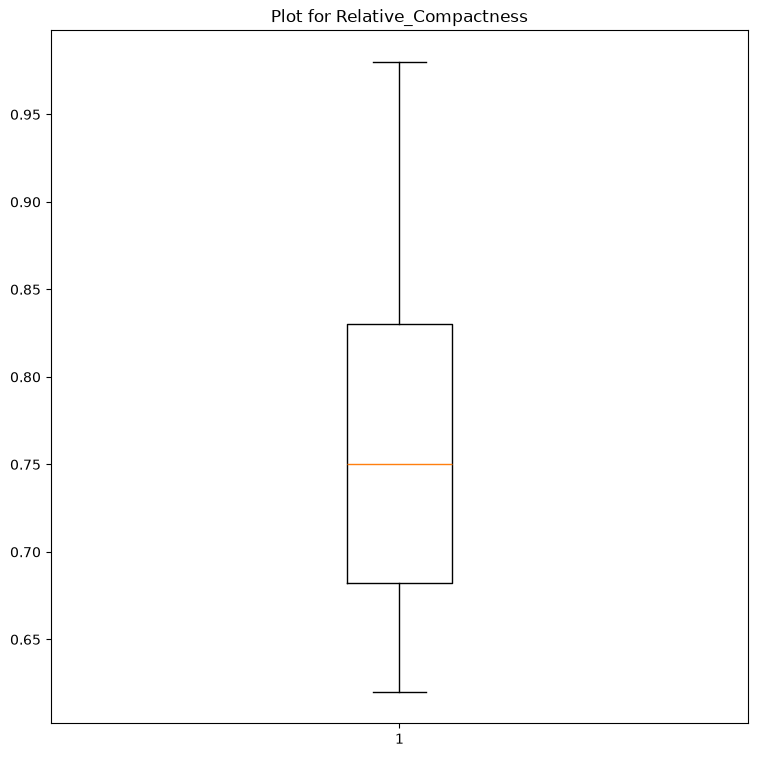

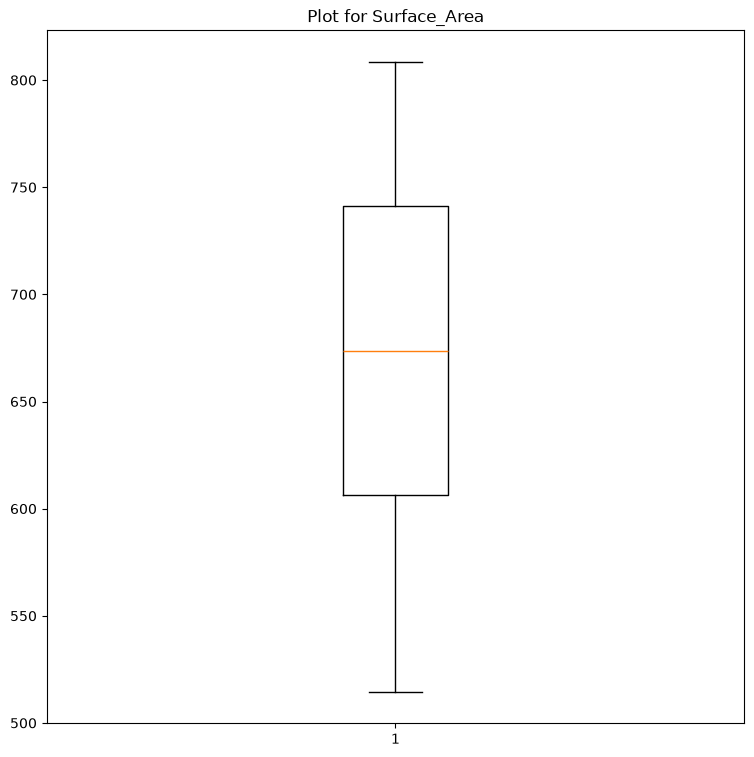

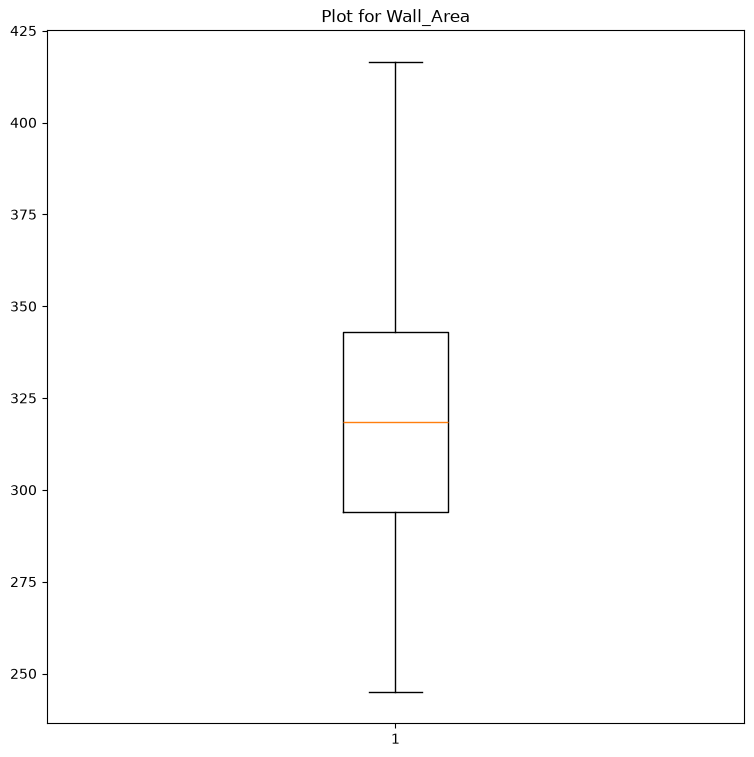

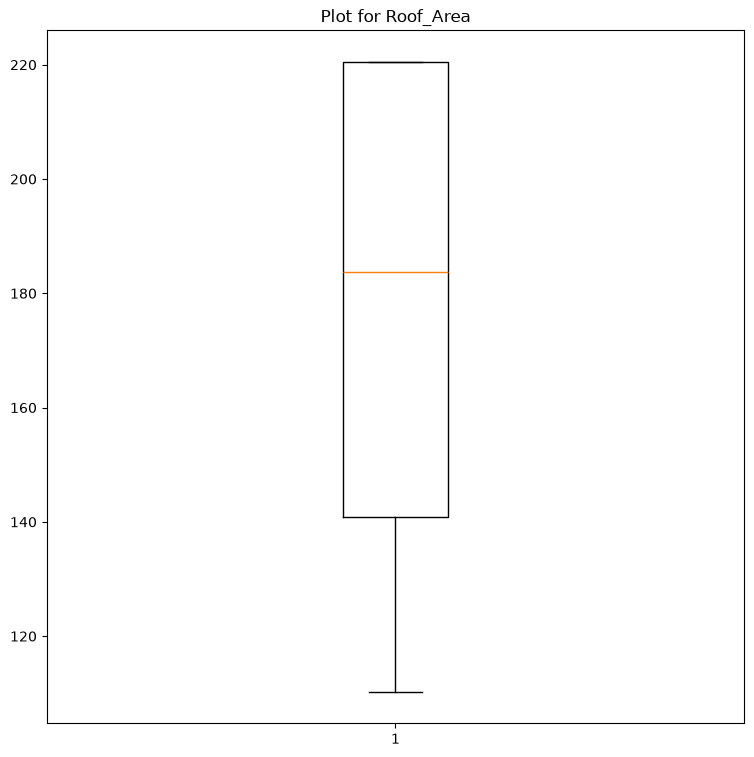

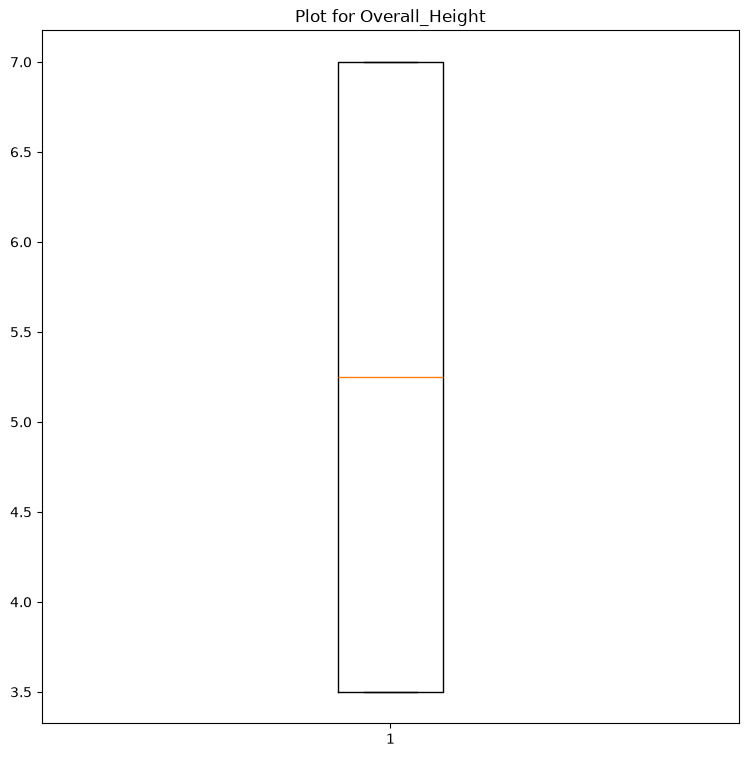

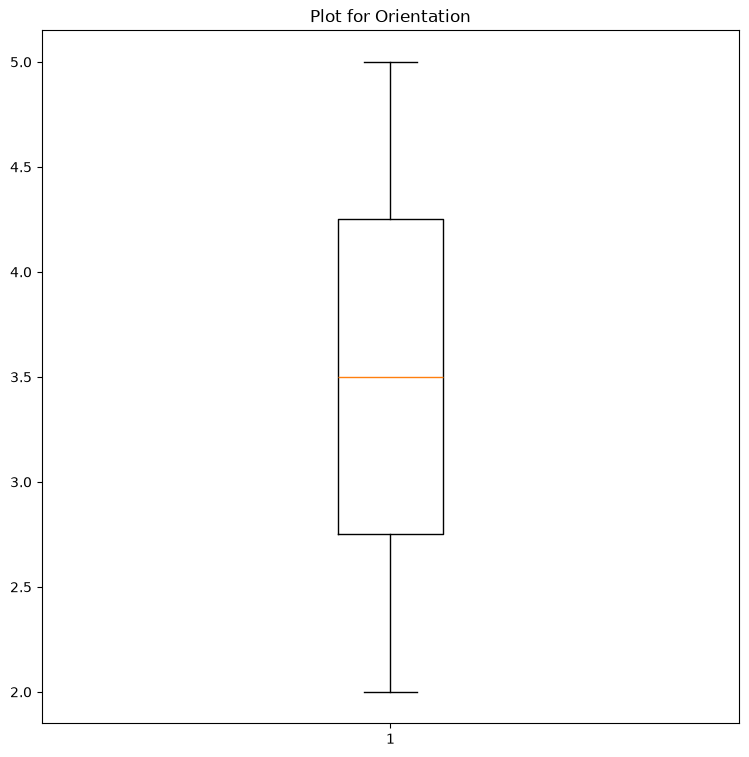

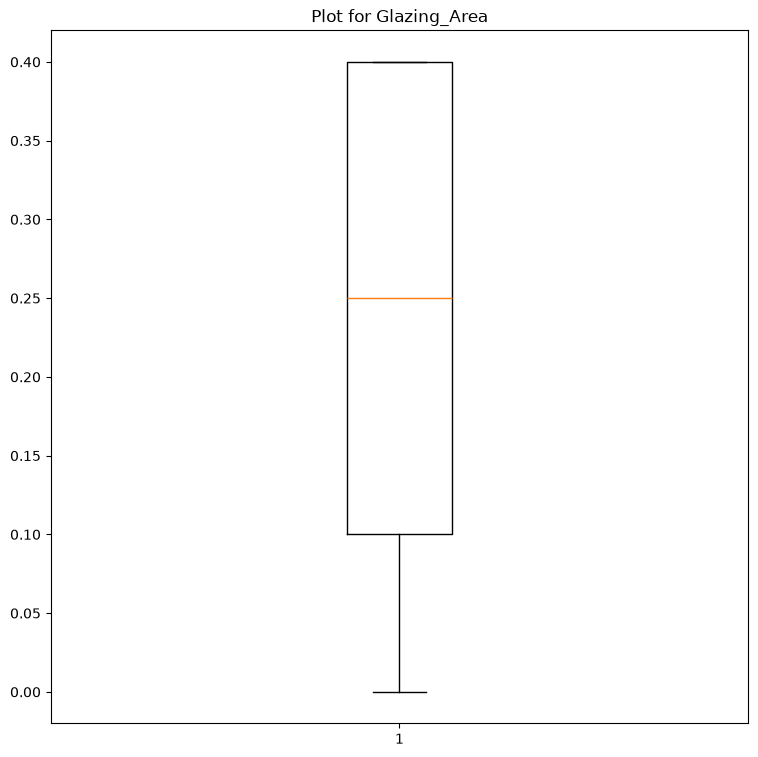

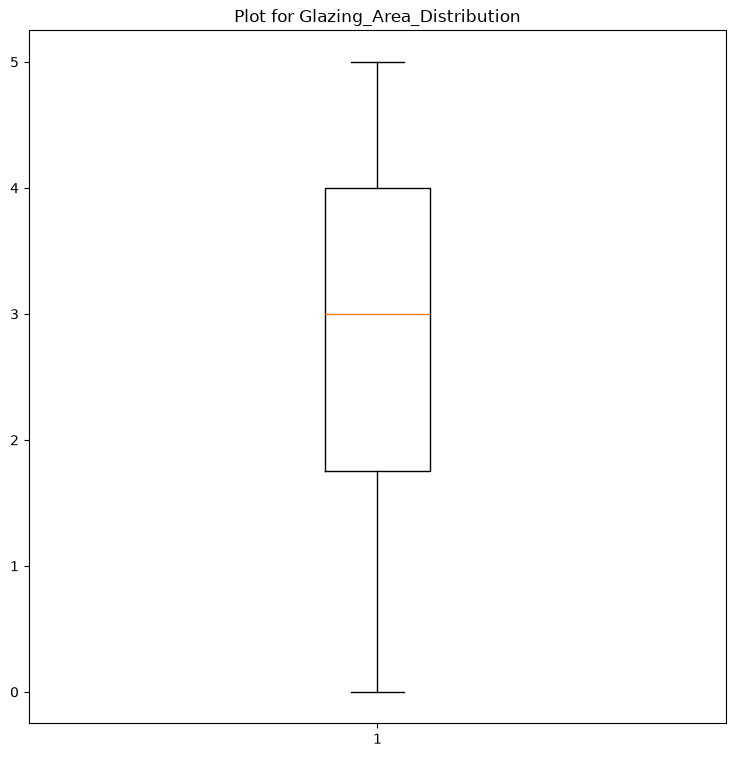

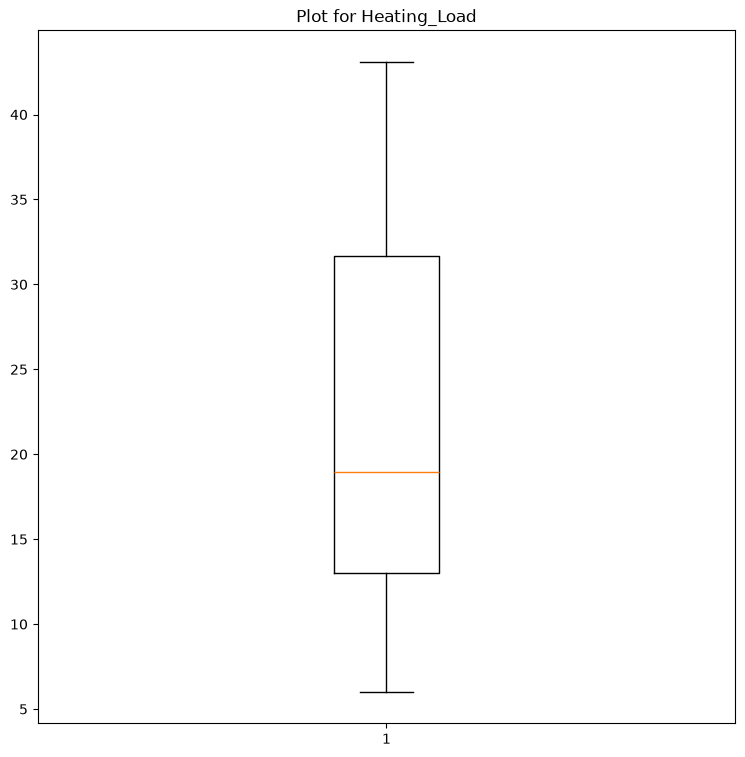

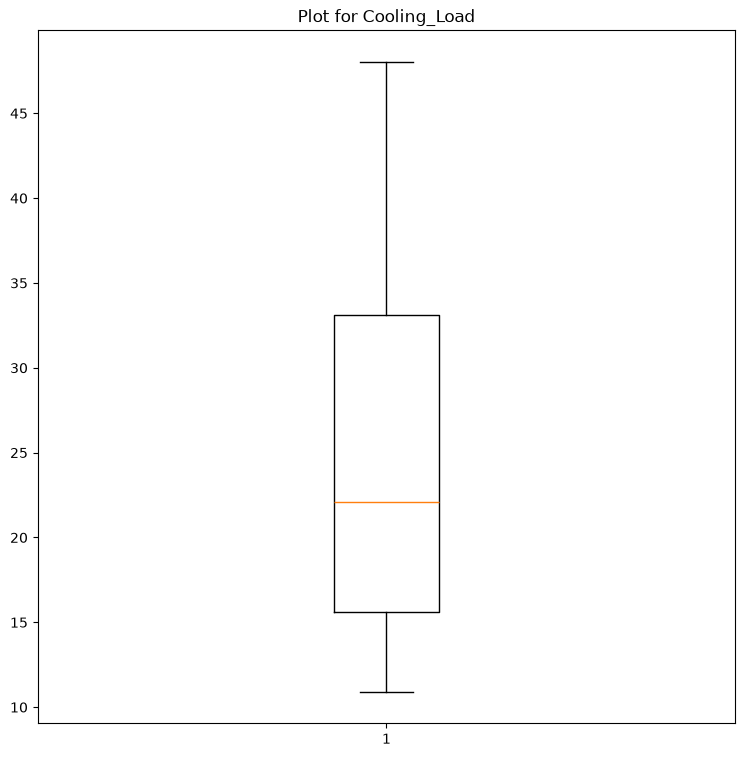

In [11]:
for col in df.columns:
    plt.figure(figsize=(9,9))
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

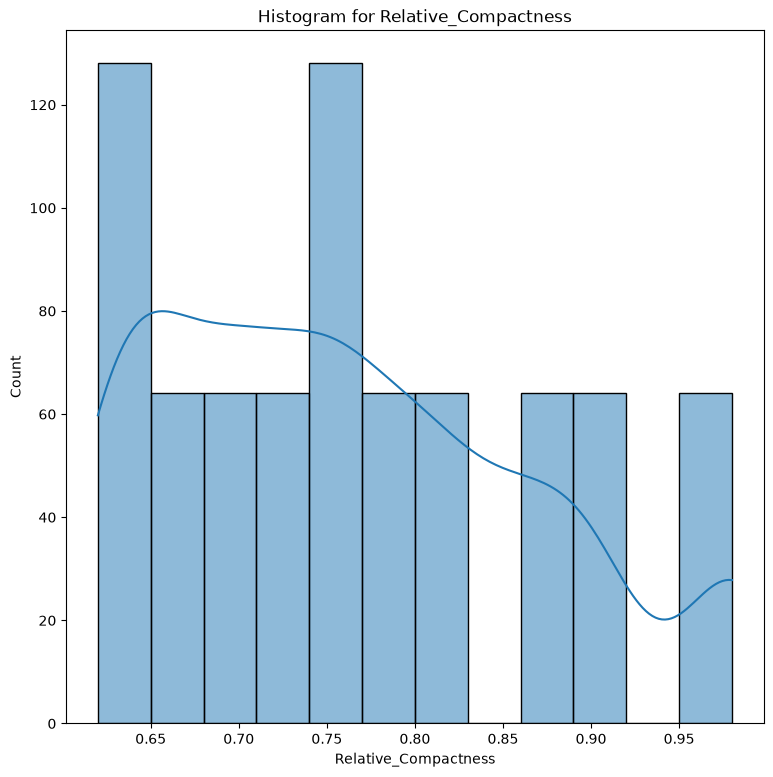

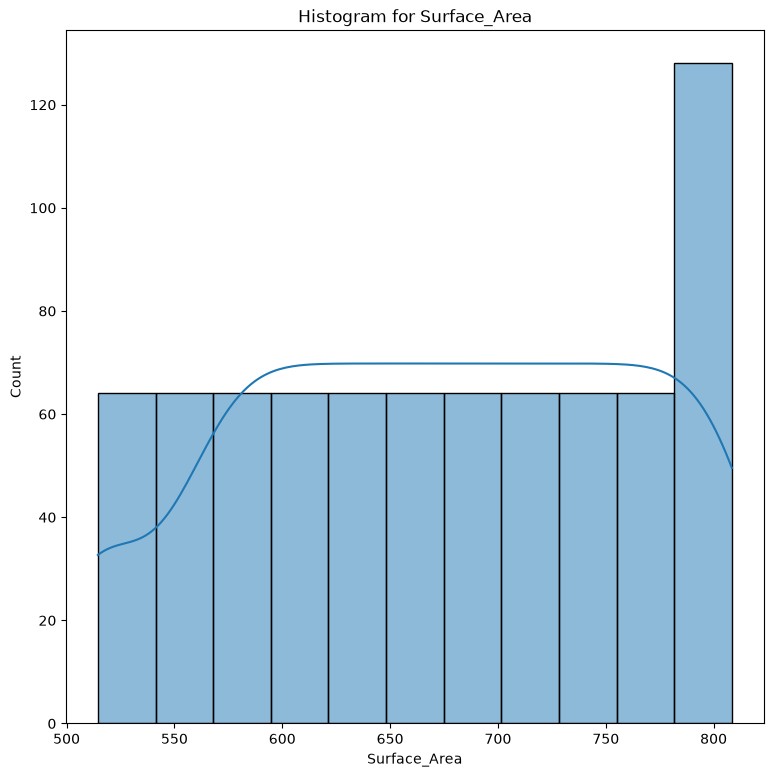

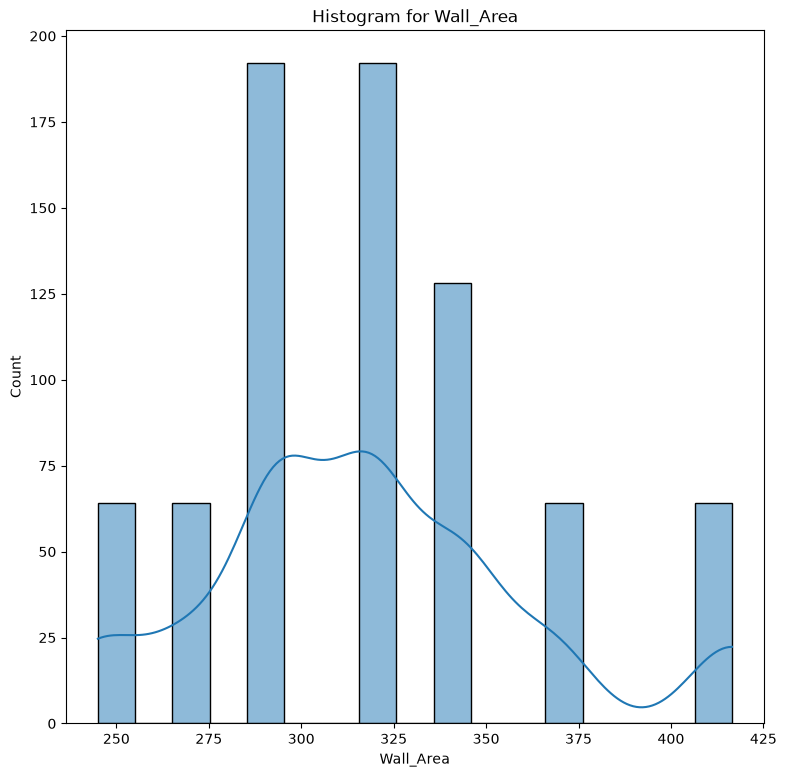

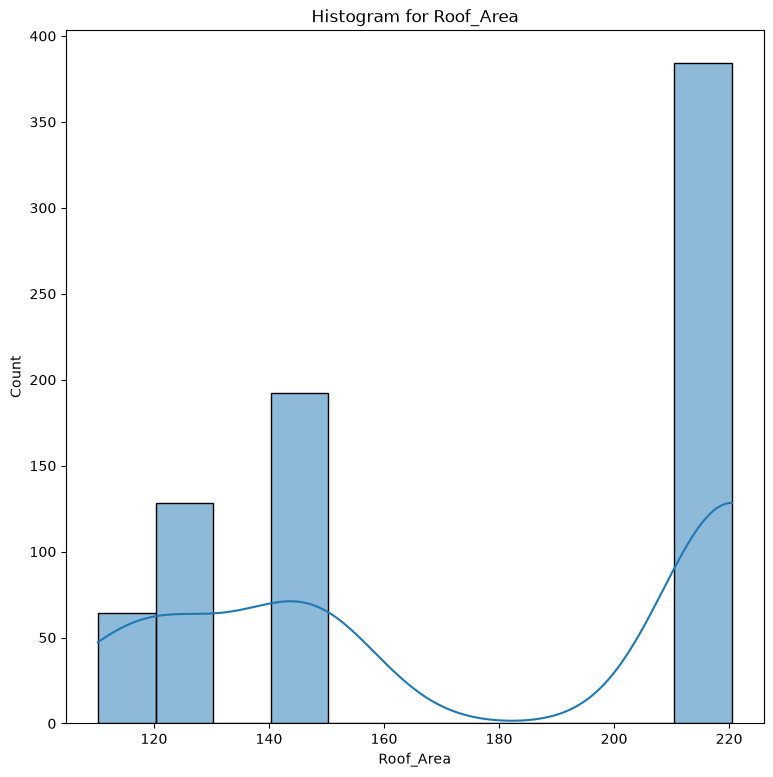

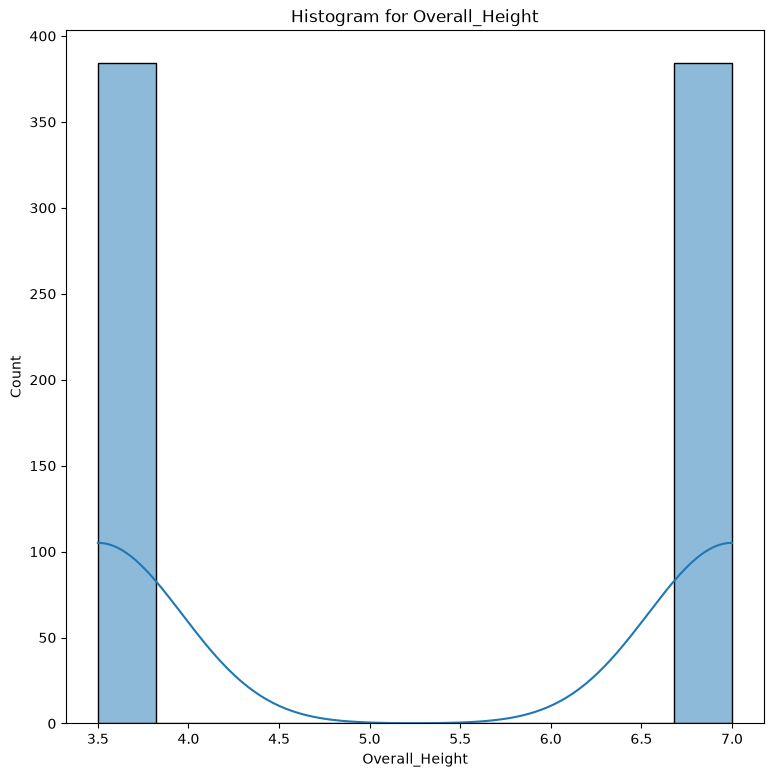

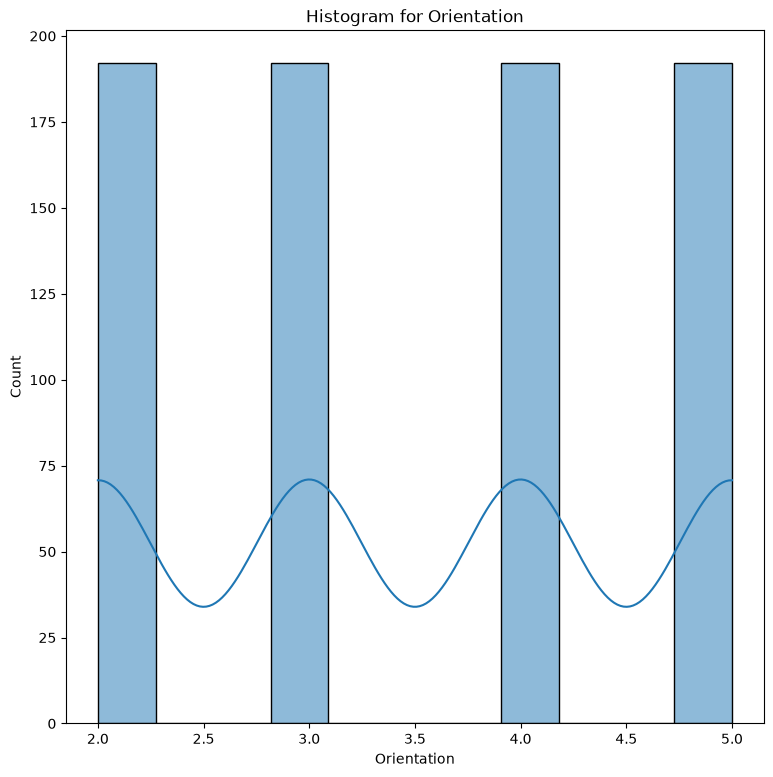

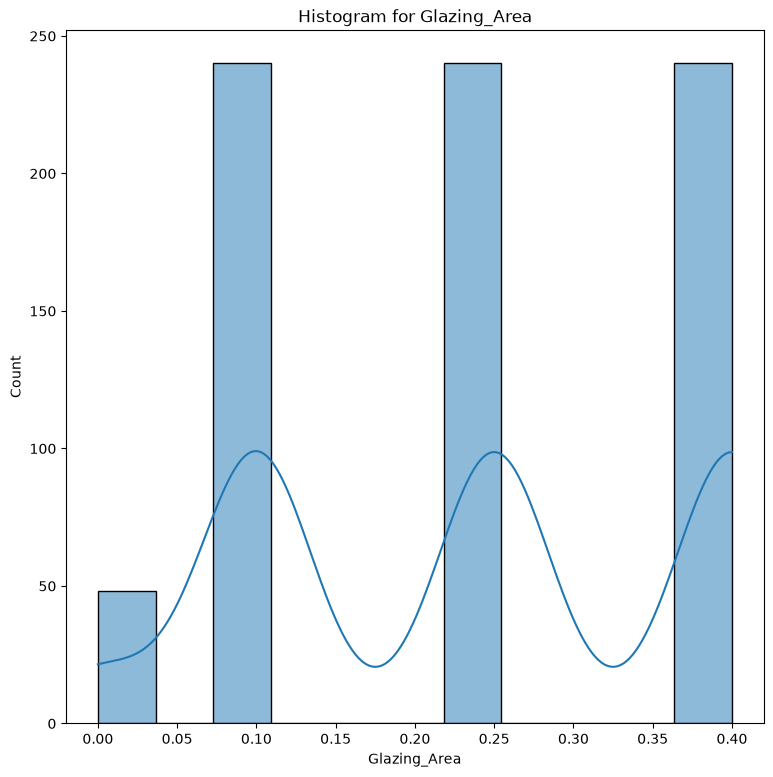

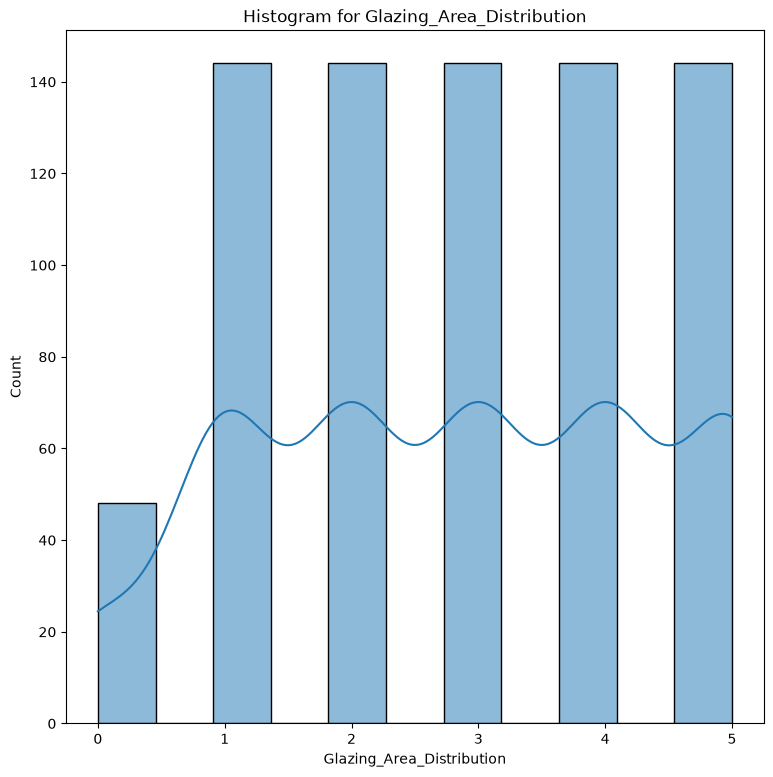

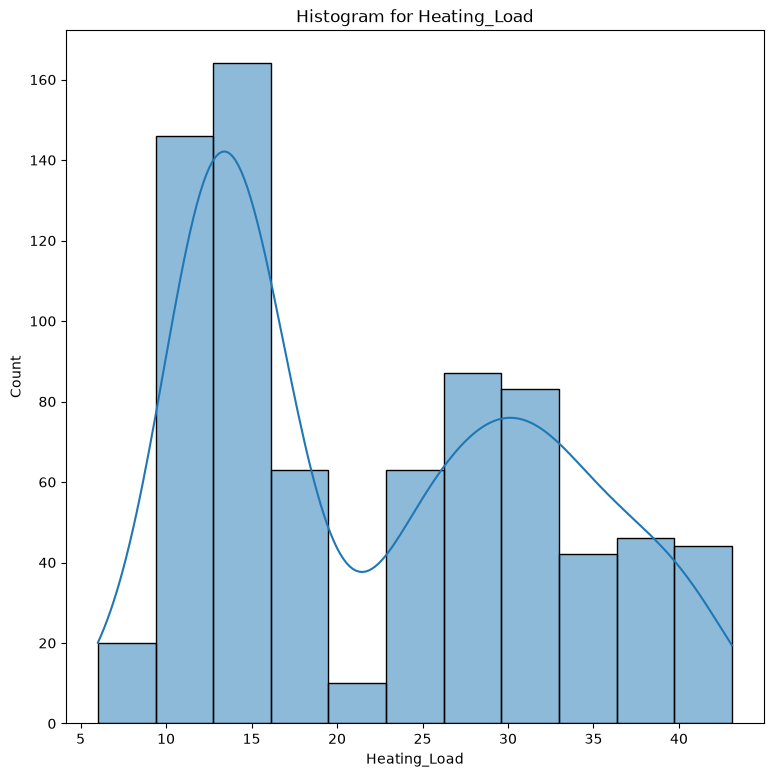

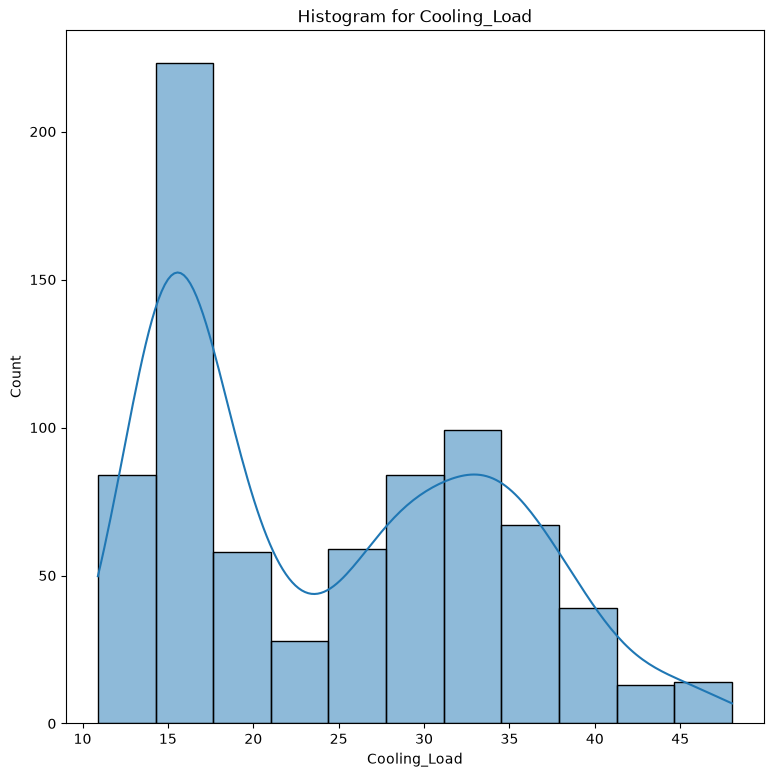

In [12]:
for col in df.columns:
    plt.figure(figsize=(9,9))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram for {col}")
    plt.show()

The distribution is pretty balanced and there are no possible outliers visible.

## 3. Scaling the values for better interpretation and clustering

In [20]:
scaler = StandardScaler()

scaled_df = df.copy()

scaled_df[scaled_df.columns] = scaler.fit_transform(scaled_df)

In [21]:
scaled_df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,2.041777,-1.785875,-0.561951,-1.470077,1.0,-1.341641,-1.760447,-1.814575,-0.670115,-0.342666
1,2.041777,-1.785875,-0.561951,-1.470077,1.0,-0.447214,-1.760447,-1.814575,-0.670115,-0.342666
2,2.041777,-1.785875,-0.561951,-1.470077,1.0,0.447214,-1.760447,-1.814575,-0.670115,-0.342666
3,2.041777,-1.785875,-0.561951,-1.470077,1.0,1.341641,-1.760447,-1.814575,-0.670115,-0.342666
4,1.284979,-1.229239,0.000000,-1.198678,1.0,-1.341641,-1.760447,-1.814575,-0.145503,0.388366


In [22]:
scaled_df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,7.680000e+02,7.680000e+02,768.000000,7.680000e+02,768.000000,768.000000,7.680000e+02,768.000000,7.680000e+02,7.680000e+02
mean,-7.401487e-17,-4.163336e-16,0.000000,2.174187e-16,0.000000,0.000000,1.480297e-16,0.000000,7.401487e-17,-2.035409e-16
std,1.000652e+00,1.000652e+00,1.000652,1.000652e+00,1.000652,1.000652,1.000652e+00,1.000652,1.000652e+00,1.000652e+00
min,-1.363812e+00,-1.785875e+00,-1.685854,-1.470077e+00,-1.000000,-1.341641,-1.760447e+00,-1.814575,-1.616203e+00,-1.439739e+00
25%,-7.725642e-01,-7.421818e-01,-0.561951,-7.915797e-01,-1.000000,-0.670820,-1.009323e+00,-0.685506,-9.237440e-01,-9.432688e-01
50%,-1.340162e-01,2.319318e-02,0.000000,1.583159e-01,0.000000,0.000000,1.173631e-01,0.120972,-3.329351e-01,-2.637774e-01
75%,6.227813e-01,7.885681e-01,0.561951,9.725122e-01,1.000000,0.670820,1.244049e+00,0.766154,9.282671e-01,8.987736e-01
max,2.041777e+00,1.553943e+00,2.247806,9.725122e-01,1.000000,1.341641,1.244049e+00,1.411336,2.062035e+00,2.465759e+00


## 4. Correlation analysis

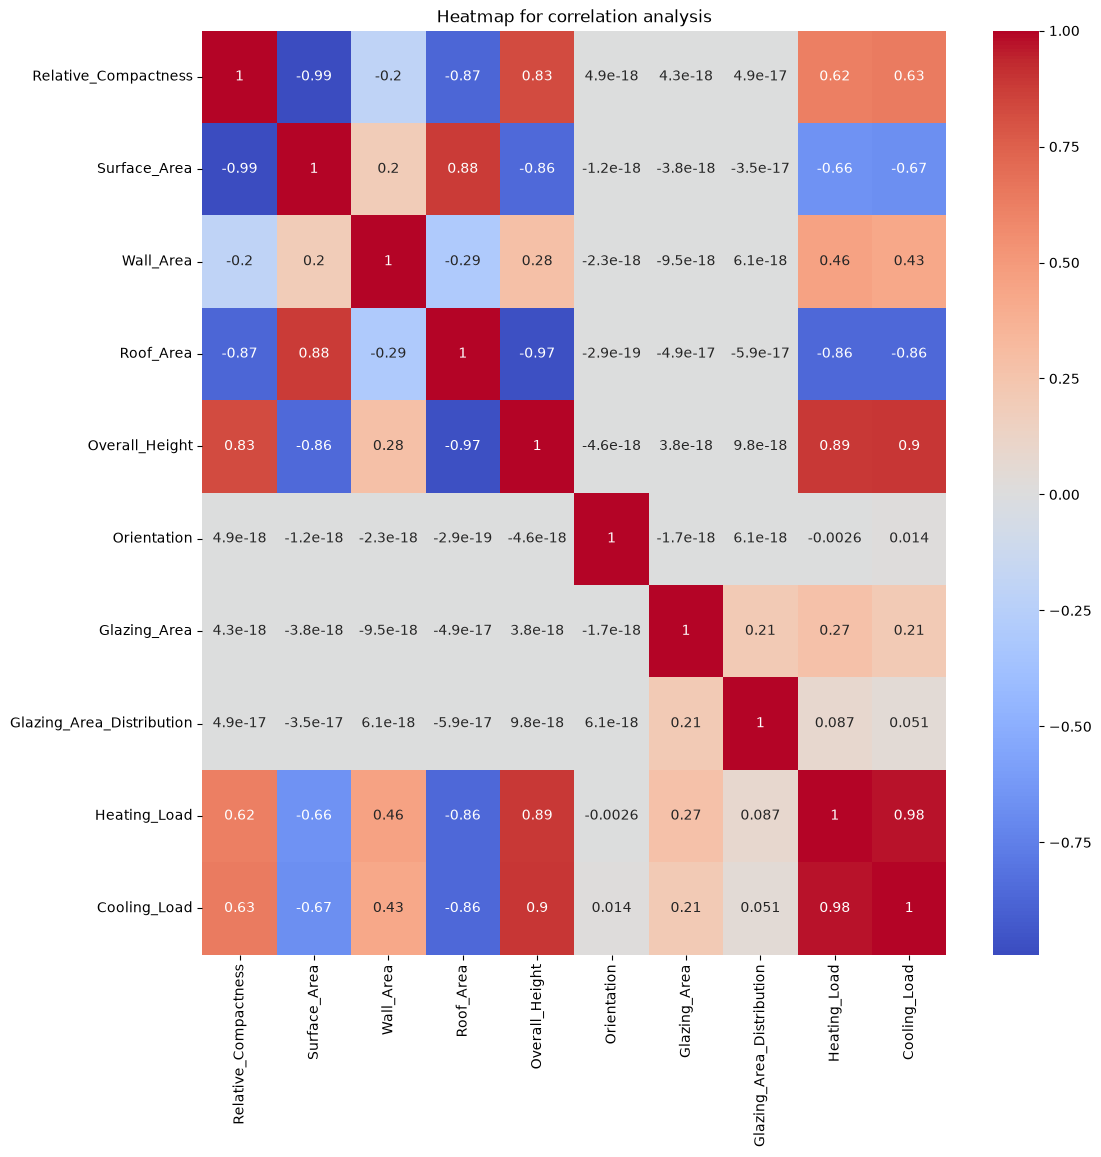

In [24]:
corr = scaled_df.select_dtypes(include='number').corr()

plt.figure(figsize=(12,12))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap for correlation analysis")
plt.show()

There are many significant positive and negative relation amongst the columns. And most of them are completely logical based on the columns present in the dataset

## 5. Finding the best value for the K for clustering

#### Elbow method for finding K

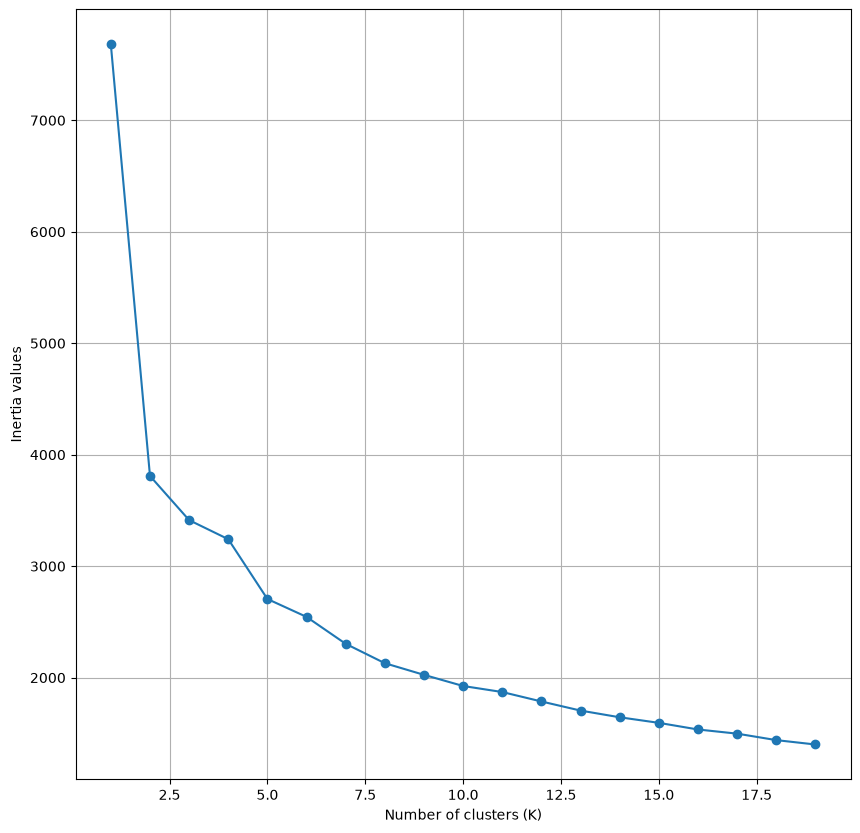

In [25]:
inertia_values = []

for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10,10))
plt.plot(range(1,20), inertia_values, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia values")
plt.grid(True)
plt.show()

#### Silhouette score method to find value of K

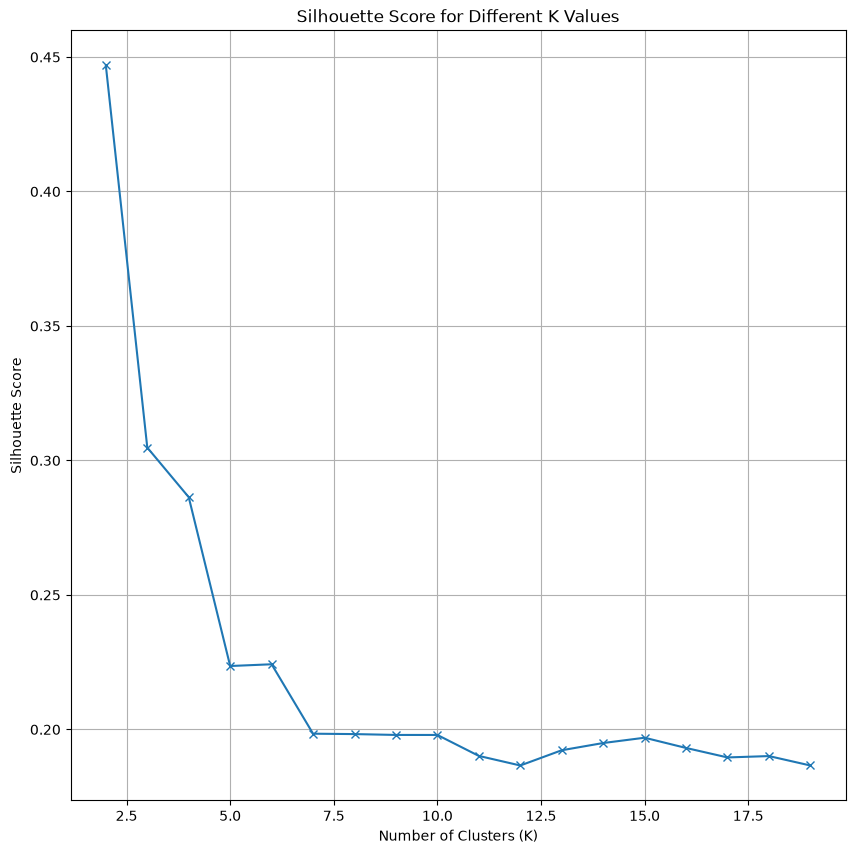

In [28]:
silhouette_scores = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 10))
plt.plot(range(2, 20), silhouette_scores, marker='x')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.grid(True)
plt.show()

k = 4 is looks like the ideal choice but we need only 2 classes for current implementation so first will move with the k = 2 then later on will test k = 4

## 6. Training the model on K = 2

In [29]:
dfcopy = df.copy()

In [30]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled_df)

dfcopy["Cluster"] = kmeans.labels_

In [31]:
dfcopy.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load,Cluster
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33,1
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33,1
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33,1
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33,1
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28,1


In [32]:
dfcopy["Cluster"].value_counts()

Cluster
1    384
0    384
Name: count, dtype: int64

## 7. PCA visualization of the clusters

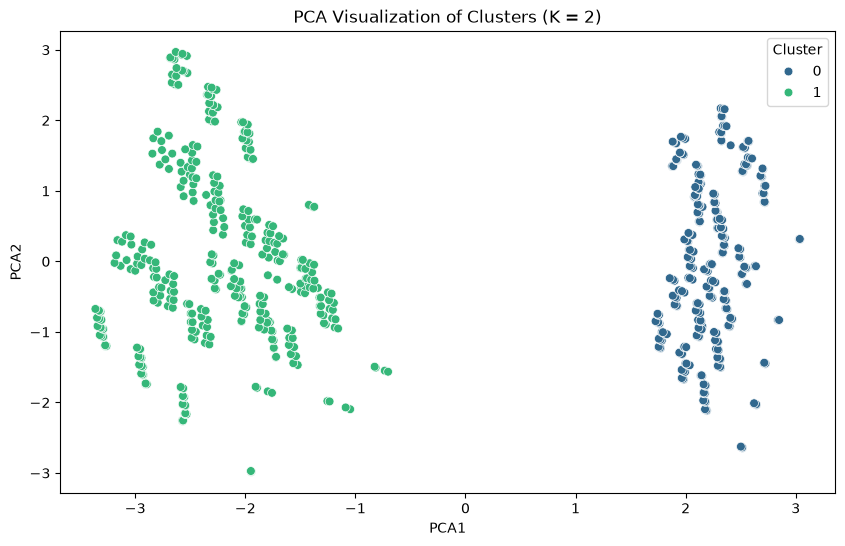

In [36]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = dfcopy['Cluster']

plt.figure(figsize=(10,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster',
                palette='viridis', data=pca_df, s=40)
plt.title("PCA Visualization of Clusters (K = 2)")
plt.show()

In [37]:
cluster_profile = dfcopy.groupby('Cluster').mean()
cluster_profile

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
Cluster,,,,,,,,,,
0,0.676667,747.250000,306.25,220.500000,3.5,3.5,0.234375,2.8125,13.338505,16.071432
1,0.851667,596.166667,330.75,132.708333,7.0,3.5,0.234375,2.8125,31.275885,33.104089


- 0 = compact and higher surface area houses so good energy efficiency
- 1 = not compact and low surface area so not good energy efficiency

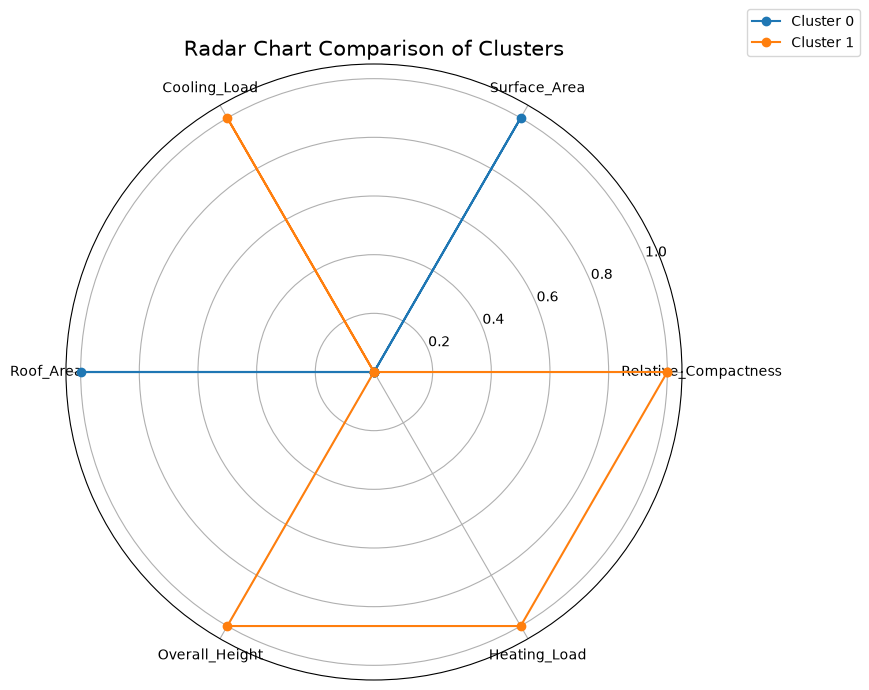

In [38]:
# Select features for radar chart
features = ['Relative_Compactness', 'Surface_Area', 'Cooling_Load', 'Roof_Area', 'Overall_Height', 'Heating_Load']
    
# Take values from cluster_profile
data = cluster_profile[features]

# Normalize the values (so everything fits nicely on radar)
data_norm = (data - data.min()) / (data.max() - data.min())

# Number of variables
num_vars = len(features)

# Calculate angles for the radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]   # complete the circle

# Start plot
plt.figure(figsize=(8, 8))

# Plot each cluster
for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]  # complete loop

    plt.polar(angles, values, marker='o', label=f'Cluster {i}')

# Add labels
plt.xticks(angles[:-1], features)
plt.title("Radar Chart Comparison of Clusters", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

In [40]:
dfcopy.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load,Cluster
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33,1
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33,1
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33,1
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33,1
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28,1


## 8. Preparing the already clustered data to now train a classification model 

In [41]:
X = dfcopy.drop("Cluster", axis=1)
y = dfcopy["Cluster"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 10)
(154, 10)
(614,)
(154,)


## 9. Training the classification model

In [43]:
model = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    class_weight='balanced',
    bootstrap=True,
    max_depth=8,
    min_samples_leaf=4,
    min_samples_split=12,
    max_features='sqrt'
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

## 10. Testing the classification model metrics

In [44]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy score: ", accuracy_score(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("\n ROC AUC score: ", roc_auc)

cm = confusion_matrix(y_test, y_pred)
print("\n Confusion matrix: \n", cm)

print("\n Classification report: \n ", classification_report(y_test, y_pred))

Accuracy score:  1.0

 ROC AUC score:  1.0

 Confusion matrix: 
 [[72  0]
 [ 0 82]]

 Classification report: 
                precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        82

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154



In [49]:
dfcopy.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load,Cluster
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760,0.500000
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306,0.500326
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000,0.000000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000,0.000000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000,0.500000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500,1.000000
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000,1.000000


## 11. Inference from model

In [50]:
df_predict_1 = pd.DataFrame({
    'Relative_Compactness': [0.83, 0.98, 0.85],
    'Surface_Area': [741.125, 808.5, 750.0],
    'Wall_Area': [343.0, 416.5, 350.0],
    'Roof_Area': [220.5, 220.5, 220.5],
    'Overall_Height': [7.0, 7.0, 7.0],
    'Orientation': [4, 5, 3],
    'Glazing_Area': [0.4, 0.4, 0.35],
    'Glazing_Area_Distribution': [4, 5, 4],
    'Heating_Load': [31.66, 43.10, 35.50],
    'Cooling_Load': [33.13, 48.03, 38.20]
})

prediction = model.predict(df_predict_1)
print("Predicted output: ", prediction)

Predicted output:  [1 1 1]


In [51]:
df_predict_0 = pd.DataFrame({
    'Relative_Compactness': [0.68, 0.62, 0.65],
    'Surface_Area': [606.37, 514.5, 550.0],
    'Wall_Area': [294.0, 245.0, 260.0],
    'Roof_Area': [140.87, 110.25, 125.5],
    'Overall_Height': [3.5, 3.5, 3.5],
    'Orientation': [2, 3, 2],
    'Glazing_Area': [0.1, 0.0, 0.05],
    'Glazing_Area_Distribution': [1, 0, 1],
    'Heating_Load': [12.99, 6.01, 10.50],
    'Cooling_Load': [15.62, 10.90, 13.00]
})

prediction = model.predict(df_predict_0)
print("Predicted output: ", prediction)

Predicted output:  [0 0 0]


In [53]:
df_undetermined = pd.DataFrame({
    'Relative_Compactness': [np.nan, 0.75, 999.99], # Missing value and extreme outlier
    'Surface_Area': [673.75, -500.0, 673.75],       # Impossible negative area
    'Wall_Area': [318.5, np.nan, 318.5],            # Missing value
    'Roof_Area': [183.75, 183.75, np.nan],          # Missing value
    'Overall_Height': [5.25, 5.25, -7.0],           # Impossible negative height
    'Orientation': [99, 3, 3],                      # Orientation out of bounds (max is 5)
    'Glazing_Area': [0.25, np.nan, 0.25],           # Missing value
    'Glazing_Area_Distribution': [3, 3, np.nan],    # Missing value
    'Heating_Load': [np.nan, 18.95, 18.95],         # Missing Target/Feature
    'Cooling_Load': [22.08, np.nan, 22.08]          # Missing Target/Feature
})

prediction = model.predict(df_undetermined)
print("Predicted output: ", prediction)

Predicted output:  [1 1 1]
